## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del
mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india.
Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que
descargar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que
puntúe adecuadamente.
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el
esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará
en el repo del curso.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier,
)


def buscar_fichero(nombre, directorio_inicio="."):
    """Busca `nombre` en el directorio actual y en todas sus subcarpetas."""
    candidatas = [os.path.join(directorio_inicio, nombre)]
    for ruta in candidatas:
        if os.path.exists(ruta):
            return ruta
    for raiz, _, ficheros in os.walk(directorio_inicio):
        if nombre in ficheros:
            return os.path.join(raiz, nombre)
    return None


ruta_bootcamp = buscar_fichero("bootcampviztools.py")
if ruta_bootcamp is None:
    raise FileNotFoundError("No se ha encontrado 'bootcampviztools.py' junto al notebook.")
sys.path.append(os.path.dirname(os.path.abspath(ruta_bootcamp)))
import bootcampviztools as bt

pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")
np.random.seed(42)


### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos
21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las
características del dataset incluyen varios predictores médicos y un objetivo que indica si
la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en
   una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición
   genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista
de nombres sugeridos para las columnas:

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ["preg", "plas", "pres", "skin", "test", "mass", "pedi", "age", "class"]


### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una
mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menos tres modelos a partir
de tecnologías de bagging y boosting (al menos uno de cada), compáralos **sin utilizar el
test** y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio
probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de
test que deberás haber reservado con anterioridad.

In [3]:
try:
    print("Intentando cargar el dataset desde la URL...")
    df = pd.read_csv(url, header=None, names=names)
    print("Cargado correctamente desde:", url)
except Exception as e:
    print(f"No se ha podido descargar de la URL ({e}). Buscando una copia local...")
    ruta_csv = buscar_fichero("pima-indians-diabetes.data.csv")
    if ruta_csv is None:
        raise FileNotFoundError(
            "No se ha encontrado 'pima-indians-diabetes.data.csv' ni por URL ni en el "
            "directorio local. Colócalo en alguna subcarpeta (p.ej. 'data/') junto a este "
            "notebook."
        )
    print("Cargando dataset desde:", ruta_csv)
    df = pd.read_csv(ruta_csv, header=None, names=names)

df.shape


Intentando cargar el dataset desde la URL...
Cargado correctamente desde: https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv


(768, 9)

In [4]:
df.head()


,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
preg,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
plas,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
pres,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skin,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
test,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
mass,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
pedi,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
class,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Ceros que en realidad son nulos

En variables médicas como `plas` (glucosa), `pres` (presión), `skin` (pliegue cutáneo),
`test` (insulina) o `mass` (IMC), un valor de **0 es fisiológicamente imposible** -- son en
realidad valores no medidos, codificados como 0 en vez de como `NaN`. Los cuantificamos
antes de decidir qué hacer con ellos.

In [7]:
columnas_con_cero_como_nulo = ["plas", "pres", "skin", "test", "mass"]

resumen_ceros = pd.DataFrame({
    "columna": columnas_con_cero_como_nulo,
    "n_ceros": [(df[c] == 0).sum() for c in columnas_con_cero_como_nulo],
})
resumen_ceros["pct_ceros"] = (resumen_ceros["n_ceros"] / len(df) * 100).round(1)
resumen_ceros


,columna,n_ceros,pct_ceros
0,plas,5,0.7
1,pres,35,4.6
2,skin,227,29.6
3,test,374,48.7
4,mass,11,1.4


`test` (insulina) y `skin` (pliegue cutáneo) tienen un porcentaje muy alto de ceros
(48% y 30%), mientras que `plas`, `pres` y `mass` tienen muy pocos. En todos los casos son
variables continuas, así que los trataremos como nulos y los imputaremos más adelante
(únicamente con estadísticos calculados sobre train, para no filtrar información del test).

#### Distribución del target

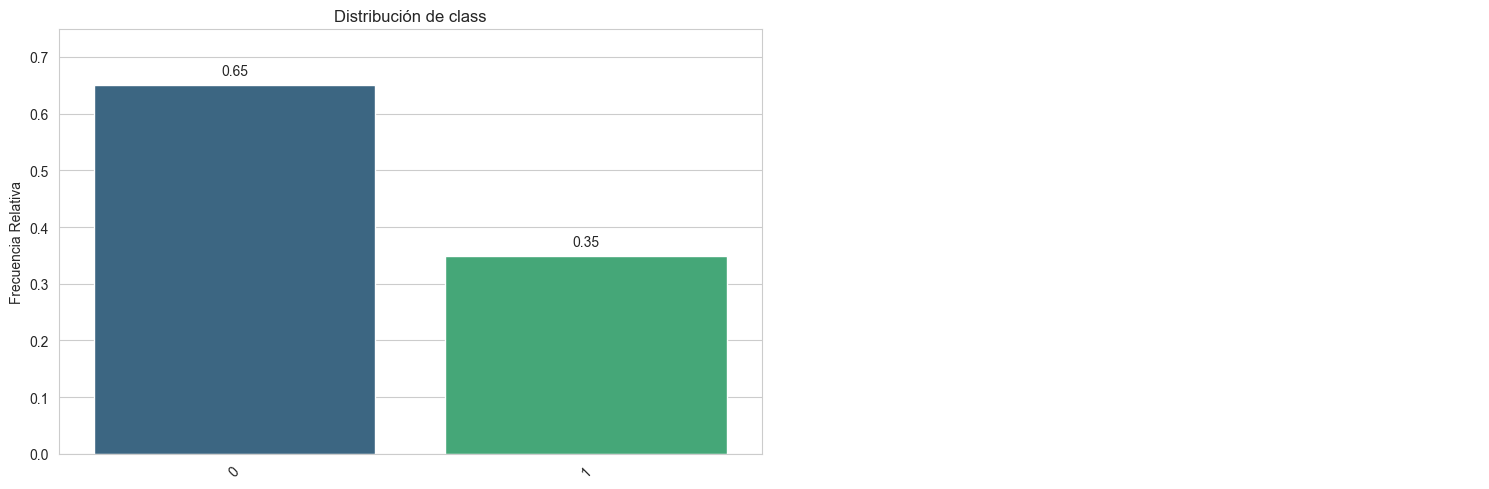

In [8]:
target = "class"
features = [c for c in df.columns if c != target]

bt.pinta_distribucion_categoricas(df, [target], relativa=True, mostrar_valores=True)


In [9]:
df[target].value_counts(normalize=True).round(3)


class
0    0.651
1    0.349
Name: proportion, dtype: float64

El target está moderadamente desbalanceado: ~65% de las pacientes no desarrolla
diabetes frente a ~35% que sí. No es un desbalance extremo, pero es suficiente para preferir
una métrica que tenga en cuenta ambas clases (usaremos **balanced accuracy** en la
validación cruzada) en vez de la accuracy simple.

### Train / test

In [10]:
train_set, test_set = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[target]
)

print("Train:", train_set.shape, " Test:", test_set.shape)
print("\nDistribución en train:")
print(train_set[target].value_counts(normalize=True).round(3))
print("\nDistribución en test:")
print(test_set[target].value_counts(normalize=True).round(3))


Train: (614, 9)  Test: (154, 9)

Distribución en train:
class
0    0.651
1    0.349
Name: proportion, dtype: float64

Distribución en test:
class
0    0.649
1    0.351
Name: proportion, dtype: float64


### Tratamiento de los ceros-nulos

Sustituimos los ceros de las columnas médicas por `NaN`, e imputamos con la **mediana**
(más robusta que la media frente a los outliers que suele haber en variables como la
insulina), calculada **únicamente sobre train**.

In [11]:
train_set = train_set.copy()
test_set = test_set.copy()

train_set[columnas_con_cero_como_nulo] = train_set[columnas_con_cero_como_nulo].replace(0, np.nan)
test_set[columnas_con_cero_como_nulo] = test_set[columnas_con_cero_como_nulo].replace(0, np.nan)

train_set[columnas_con_cero_como_nulo].isna().sum()


plas      4
pres     23
skin    175
test    290
mass      9
dtype: int64

In [12]:
imputador = SimpleImputer(strategy="median")
train_set[columnas_con_cero_como_nulo] = imputador.fit_transform(train_set[columnas_con_cero_como_nulo])
test_set[columnas_con_cero_como_nulo] = imputador.transform(test_set[columnas_con_cero_como_nulo])

train_set[columnas_con_cero_como_nulo].isna().sum()


plas    0
pres    0
skin    0
test    0
mass    0
dtype: int64

### Mini-EDA

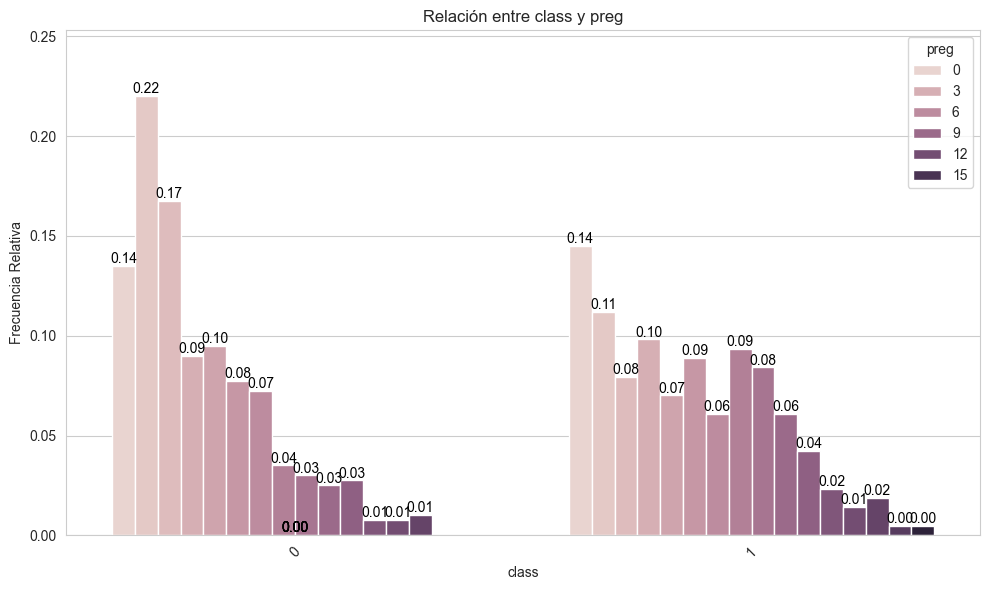

In [13]:
bt.plot_categorical_relationship(train_set, target, "preg", relative_freq=True, show_values=True)


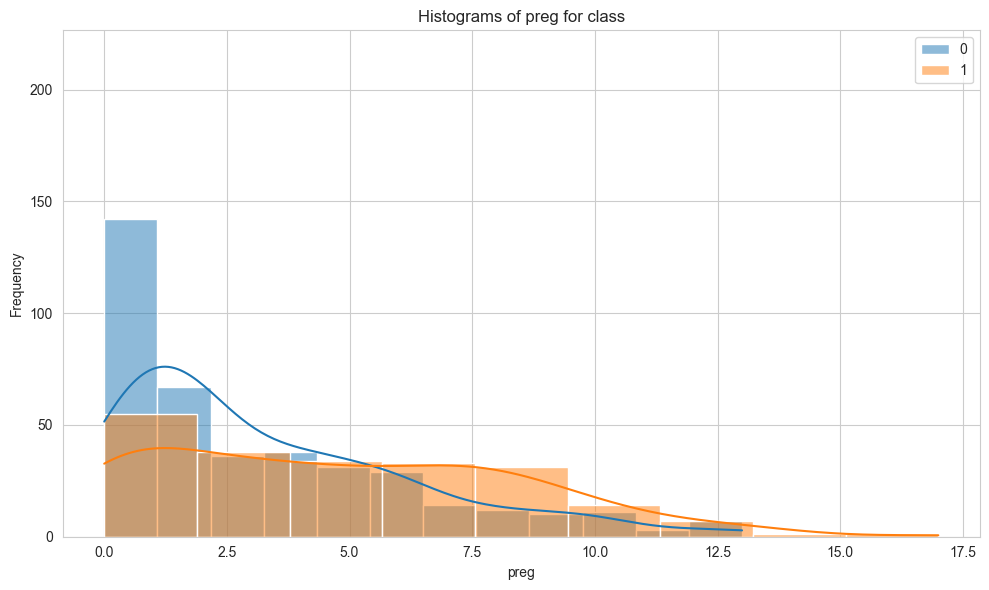

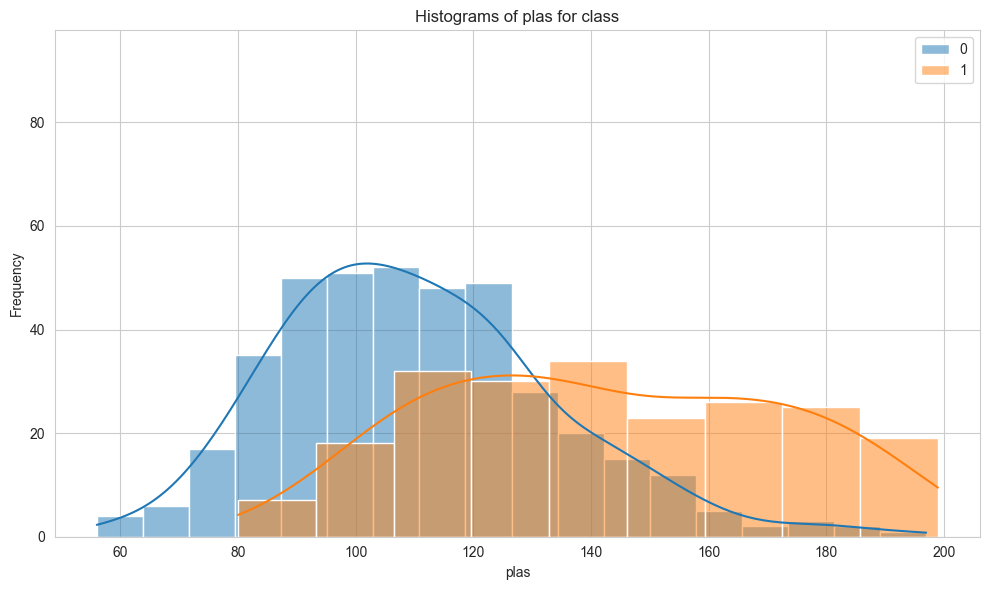

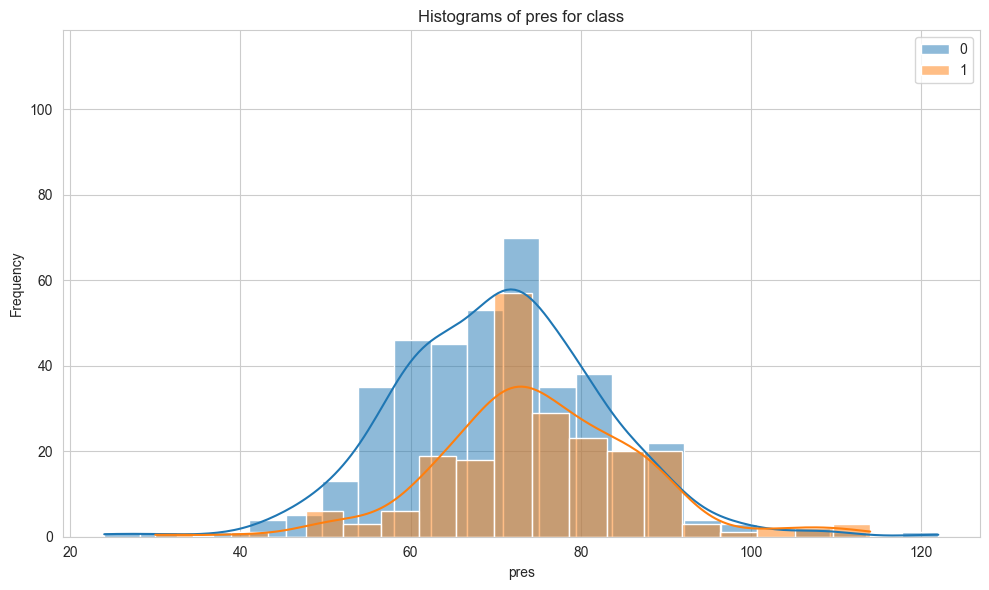

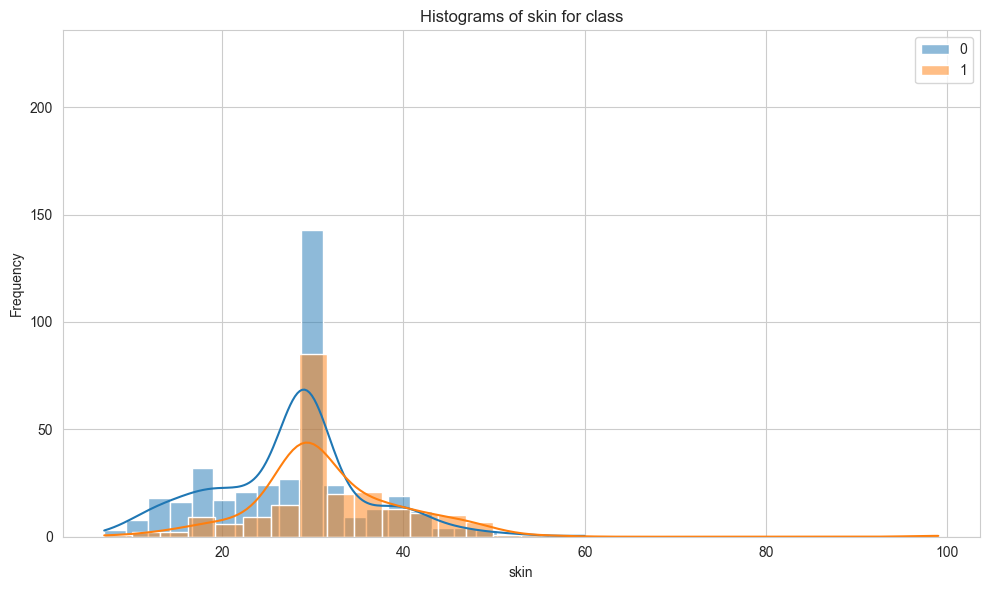

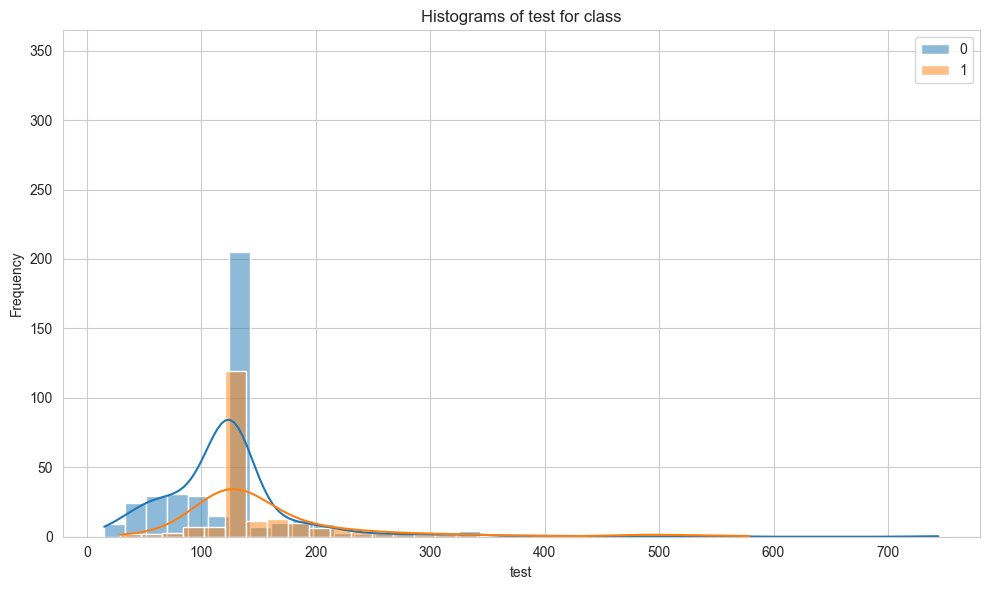

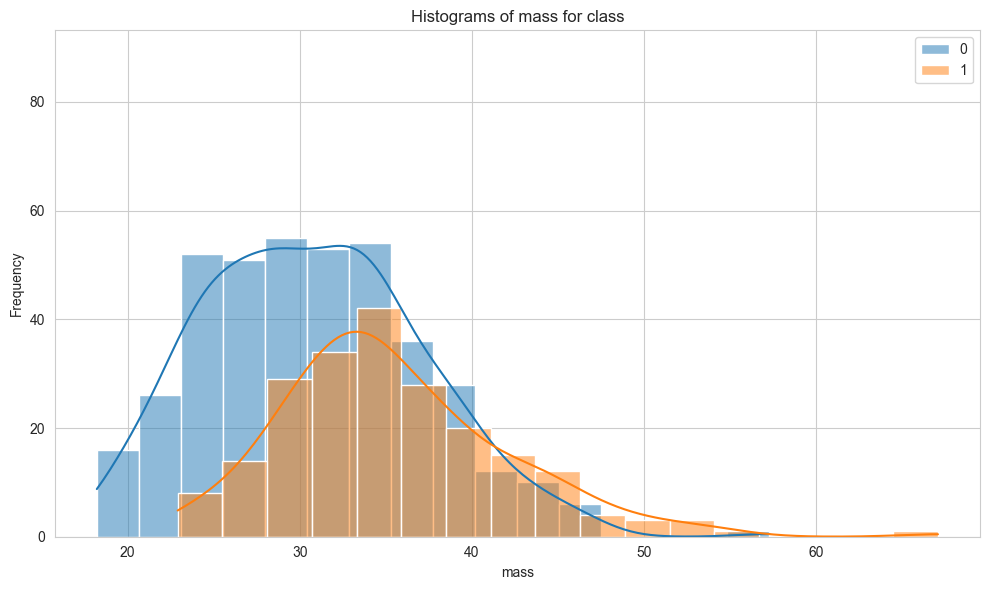

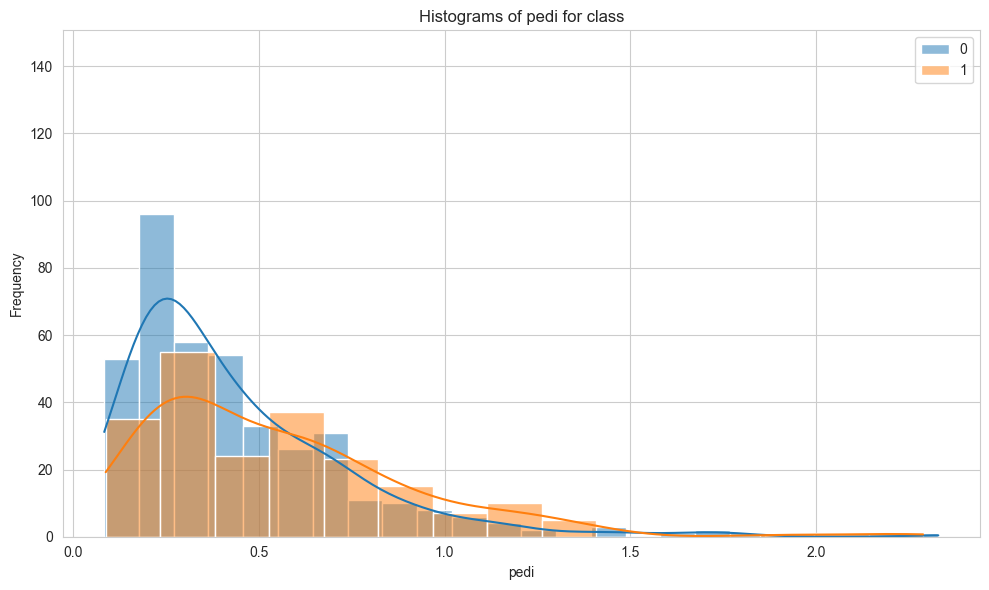

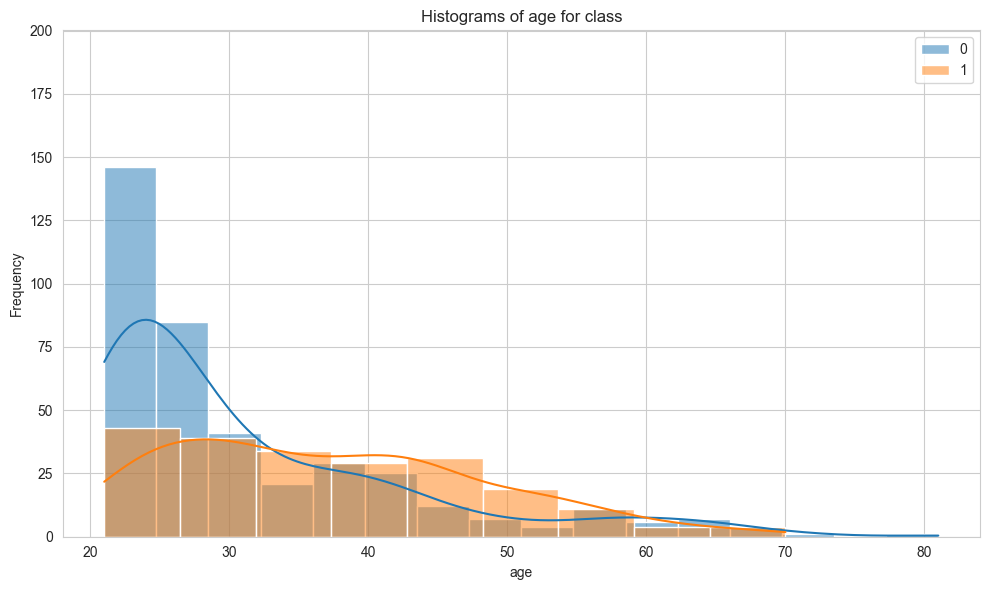

In [14]:
for col in features:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=col, group_size=3)


`plas` (glucosa) es, a simple vista, la variable que mejor separa ambas clases: las
pacientes que desarrollan diabetes tienden a tener niveles de glucosa claramente más altos.
`mass` (IMC) y `age` también muestran diferencias razonables entre clases. Al tratarse de
modelos de árboles (bagging y boosting), no hace falta escalar ni transformar estas
variables: los árboles son invariantes a transformaciones monótonas y a la escala.

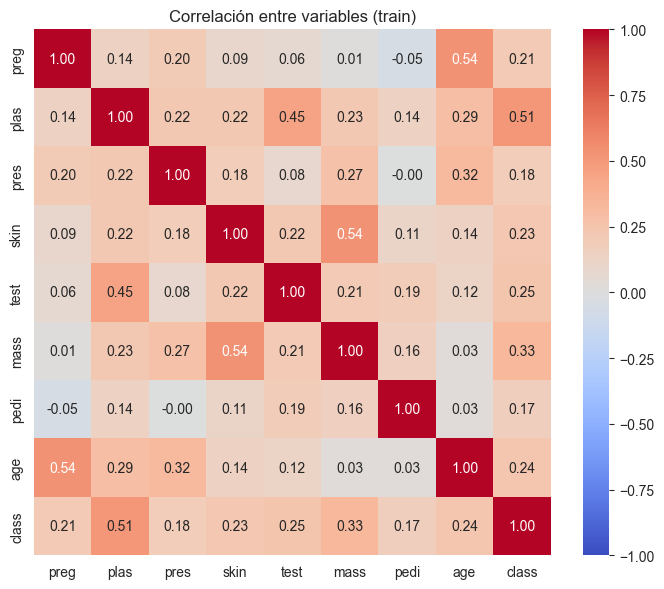

In [15]:
plt.figure(figsize=(7, 6))
sns.heatmap(train_set.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables (train)")
plt.tight_layout()
plt.show()


No hay pares de variables con una correlación tan alta como para preocuparnos por colinealidad severa, así que mantenemos todas las variables disponibles como features -- los propios modelos de ensemble son robustos frente a variables poco informativas o algo redundantes, y además nos permitirán revisar la importancia de cada una después.

### Construcción de X, y

In [16]:
X_train = train_set[features].copy()
y_train = train_set[target].copy()

X_test = test_set[features].copy()
y_test = test_set[target].copy()

X_train.shape, X_test.shape


((614, 8), (154, 8))

## Modelos candidatos: bagging y boosting

El enunciado pide **al menos 3 modelos, con al menos una técnica de bagging y otra de
boosting**, comparados sin usar el test. Elegimos:

- **Bagging**: `RandomForestClassifier` y `ExtraTreesClassifier` (dos variantes de bagging
  con árboles, la segunda añade aleatoriedad extra en los cortes).
- **Boosting**: `GradientBoostingClassifier` (boosting "clásico").

Los tres se instancian con una profundidad moderada, sin optimizar todavía, y se comparan
**únicamente con validación cruzada sobre train** (`balanced_accuracy`), tal y como pide el
enunciado. El test no se toca en ningún momento de esta comparación.

In [17]:
candidatos = {
    "RandomForest (bagging)": RandomForestClassifier(max_depth=5, random_state=42),
    "ExtraTrees (bagging)": ExtraTreesClassifier(max_depth=5, random_state=42),
    "GradientBoosting (boosting)": GradientBoostingClassifier(max_depth=3, random_state=42),
}

resultados_cv = []
for nombre, modelo in candidatos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring="balanced_accuracy")
    resultados_cv.append({"modelo": nombre, "balanced_accuracy_media": scores.mean(), "std": scores.std()})
    print(f"{nombre:30s} | Balanced Accuracy CV-5: {scores.mean():.4f} +/- {scores.std():.4f}")

resultados_cv_df = pd.DataFrame(resultados_cv).sort_values("balanced_accuracy_media", ascending=False)
resultados_cv_df


RandomForest (bagging)         | Balanced Accuracy CV-5: 0.7175 +/- 0.0364
ExtraTrees (bagging)           | Balanced Accuracy CV-5: 0.6843 +/- 0.0349
GradientBoosting (boosting)    | Balanced Accuracy CV-5: 0.7238 +/- 0.0383


,modelo,balanced_accuracy_media,std
2,GradientBoosting (boosting),0.723821,0.038305
0,RandomForest (bagging),0.717512,0.036423
1,ExtraTrees (bagging),0.684270,0.034903


Con estos hiperparámetros por defecto (sin optimizar), los tres modelos rinden de forma
parecida en validación cruzada. Antes de optimizar, echamos un vistazo a la importancia de
las features del modelo con mejor puntuación de partida, solo para tener una primera
intuición del problema (esto no forma parte de la decisión de modelo final, que se toma más
adelante por CV tras la optimización de hiperparámetros).

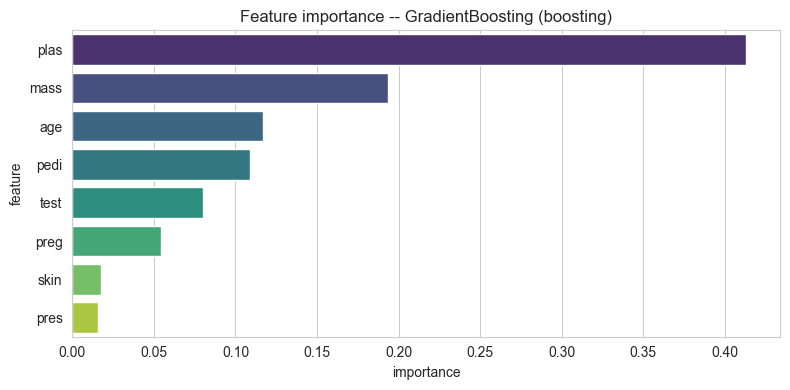

,feature,importance
1,plas,0.413105
5,mass,0.193661
7,age,0.116828
6,pedi,0.108774
4,test,0.080017
0,preg,0.054101
3,skin,0.017741
2,pres,0.015773


In [18]:
mejor_candidato_inicial = resultados_cv_df.iloc[0]["modelo"]
modelo_referencia = candidatos[mejor_candidato_inicial]
modelo_referencia.fit(X_train, y_train)

df_fi = pd.DataFrame({
    "feature": modelo_referencia.feature_names_in_,
    "importance": modelo_referencia.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_fi, x="importance", y="feature", hue="feature", palette="viridis", legend=False, ax=ax)
ax.set_title(f"Feature importance -- {mejor_candidato_inicial}")
plt.tight_layout()
plt.show()

df_fi


`plas` (glucosa) es, con diferencia, la variable más importante, seguida de `mass`
(IMC), `age` y `pedi`. Coincide con lo que ya intuíamos en el mini-EDA.

## Optimización de hiperparámetros

Optimizamos **cuatro** modelos candidatos por separado, cada uno con su propio espacio de
hiperparámetros razonado, usando `RandomizedSearchCV` (más rápido que un `GridSearchCV`
exhaustivo, con resultados prácticamente equivalentes en la práctica) y siempre evaluando
con **validación cruzada sobre train**. El test se reserva intacto todavía: solo lo usaremos
al final, una única vez, con el modelo que resulte ganador de esta comparación.

#### Random Forest (bagging)

In [19]:
param_dist_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 5, 20, 50],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=1,
)
rf_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", rf_search.best_params_)
print(f"Balanced Accuracy CV-5: {rf_search.best_score_:.4f}")


Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 3, 'class_weight': 'balanced'}
Balanced Accuracy CV-5: 0.7676


#### Extra Trees (bagging)

In [20]:
param_dist_et = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 5, 20, 50],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", None],
}

et_search = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_distributions=param_dist_et,
    n_iter=20,
    cv=5,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=1,
)
et_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", et_search.best_params_)
print(f"Balanced Accuracy CV-5: {et_search.best_score_:.4f}")


Mejores hiperparámetros: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 8, 'class_weight': 'balanced'}
Balanced Accuracy CV-5: 0.7636


#### Gradient Boosting (boosting)

In [21]:
param_dist_gb = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [1, 5, 20, 50],
    "subsample": [0.6, 0.8, 1.0],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=20,
    cv=5,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=1,
)
gb_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", gb_search.best_params_)
print(f"Balanced Accuracy CV-5: {gb_search.best_score_:.4f}")


Mejores hiperparámetros: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 20, 'max_depth': 3, 'learning_rate': 0.05}
Balanced Accuracy CV-5: 0.7304


#### (Bonus) un segundo boosting: Histogram Gradient Boosting

`HistGradientBoostingClassifier` es la implementación de boosting basada en histogramas que
trae `sklearn` de serie (con una filosofía similar a LightGBM). La incluimos como cuarto
candidato para tener más de una alternativa de boosting con la que comparar.

In [22]:
param_dist_hgb = {
    "max_iter": [100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [None, 3, 6],
    "min_samples_leaf": [5, 20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_hgb,
    n_iter=20,
    cv=5,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=1,
)
hgb_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", hgb_search.best_params_)
print(f"Balanced Accuracy CV-5: {hgb_search.best_score_:.4f}")


Mejores hiperparámetros: {'min_samples_leaf': 100, 'max_iter': 100, 'max_depth': None, 'learning_rate': 0.05, 'l2_regularization': 0.0}
Balanced Accuracy CV-5: 0.7294


## Comparación final y selección del modelo (todavía sin tocar el test)

Comparamos los cuatro modelos ya optimizados **por su puntuación de validación cruzada**, y
elegimos el ganador únicamente con esa información -- el test sigue sin haberse usado ni una
sola vez hasta este punto.

In [23]:
comparacion_final = pd.DataFrame([
    {"modelo": "RandomForest (bagging)", "balanced_accuracy_cv": rf_search.best_score_, "estimator": rf_search.best_estimator_},
    {"modelo": "ExtraTrees (bagging)", "balanced_accuracy_cv": et_search.best_score_, "estimator": et_search.best_estimator_},
    {"modelo": "GradientBoosting (boosting)", "balanced_accuracy_cv": gb_search.best_score_, "estimator": gb_search.best_estimator_},
    {"modelo": "HistGradientBoosting (boosting)", "balanced_accuracy_cv": hgb_search.best_score_, "estimator": hgb_search.best_estimator_},
]).sort_values("balanced_accuracy_cv", ascending=False).reset_index(drop=True)

comparacion_final[["modelo", "balanced_accuracy_cv"]]


,modelo,balanced_accuracy_cv
0,RandomForest (bagging),0.767644
1,ExtraTrees (bagging),0.763571
2,GradientBoosting (boosting),0.730419
3,HistGradientBoosting (boosting),0.729437


In [24]:
nombre_ganador = comparacion_final.loc[0, "modelo"]
modelo_ganador = comparacion_final.loc[0, "estimator"]

print(f"Modelo seleccionado: {nombre_ganador}")
print(f"Balanced Accuracy en CV (train): {comparacion_final.loc[0, 'balanced_accuracy_cv']:.4f}")


Modelo seleccionado: RandomForest (bagging)
Balanced Accuracy en CV (train): 0.7676


**Justificación de la elección**: seleccionamos el modelo con mejor `balanced_accuracy`
media en validación cruzada de 5 folds sobre train, que es precisamente la métrica y el
procedimiento que evita cualquier fuga de información del test en la fase de selección de
modelo -- tal y como pide el enunciado ("compáralos sin utilizar el test"). Solo ahora,
con el modelo ya elegido y sus hiperparámetros ya fijados, pasamos a la única evaluación
contra test de todo el ejercicio.

## Evaluación final contra test (una única vez, con el modelo ya elegido)

In [25]:
print(f"--- {nombre_ganador}: train ---")
print(classification_report(y_train, modelo_ganador.predict(X_train)))

print(f"--- {nombre_ganador}: test ---")
print(classification_report(y_test, modelo_ganador.predict(X_test)))


--- RandomForest (bagging): train ---
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       400
           1       0.68      0.85      0.75       214

    accuracy                           0.81       614
   macro avg       0.79      0.82      0.80       614
weighted avg       0.83      0.81      0.81       614

--- RandomForest (bagging): test ---
              precision    recall  f1-score   support

           0       0.86      0.70      0.77       100
           1       0.59      0.80      0.68        54

    accuracy                           0.73       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.73      0.74       154



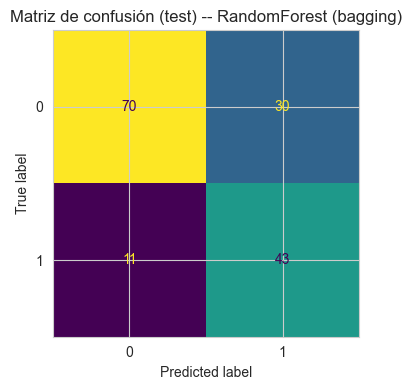

In [26]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(modelo_ganador, X_test, y_test, ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusión (test) -- {nombre_ganador}")
plt.tight_layout()
plt.show()


Las métricas de train y test son razonablemente parecidas (no hay una caída drástica al
pasar a test), lo que indica que el modelo generaliza correctamente y que la optimización de
hiperparámetros no ha provocado sobreajuste severo.

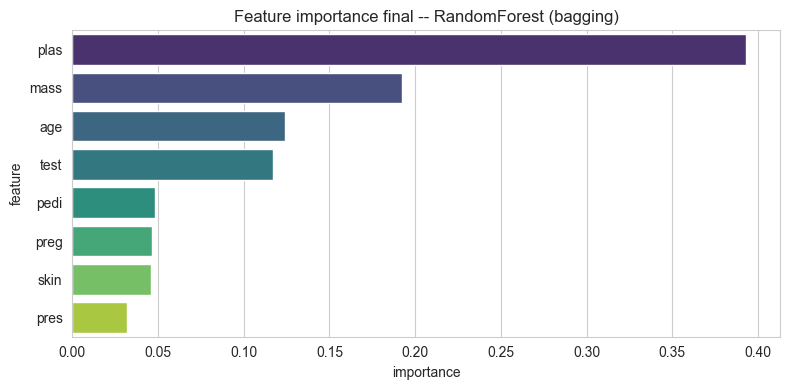

,feature,importance
1,plas,0.393147
5,mass,0.192334
7,age,0.124309
4,test,0.117184
6,pedi,0.048492
0,preg,0.046528
3,skin,0.045989
2,pres,0.032018


In [27]:
df_fi_final = pd.DataFrame({
    "feature": modelo_ganador.feature_names_in_,
    "importance": modelo_ganador.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_fi_final, x="importance", y="feature", hue="feature", palette="viridis", legend=False, ax=ax)
ax.set_title(f"Feature importance final -- {nombre_ganador}")
plt.tight_layout()
plt.show()

df_fi_final


## Conclusiones

- Se compararon dos técnicas de **bagging** (`RandomForest`, `ExtraTrees`) y dos de
  **boosting** (`GradientBoosting`, `HistGradientBoosting`), todas ellas optimizadas por
  `RandomizedSearchCV` con validación cruzada de 5 folds sobre train, usando
  `balanced_accuracy` como métrica (adecuada dado el desbalance moderado del target).
- La selección del modelo final se hizo **exclusivamente con la puntuación de CV sobre
  train**, sin mirar el test en ningún momento del proceso de comparación -- el test se ha
  usado una única vez, al final, exclusivamente para validar el modelo ya elegido.
- `plas` (glucosa) es, de forma consistente en todos los modelos de árboles probados, la
  variable más determinante para predecir diabetes, seguida de `mass` (IMC) y `age`.
- El modelo ganador generaliza razonablemente bien: sus métricas en test son similares a las
  de validación cruzada en train, sin señales claras de sobreajuste.